# Time-dependent missingness in a latent time series

In some time series, values don’t go missing for purely random reasons.
instead, whether something gets recorded can depend on what the system
is doing underneath.

This notebook walks through a simple way to model that situation in pymc.
the main idea is to treat missingness as part of the data-generating process,
rather than something to handle separately in preprocessing.

## Intuition

We assume there is a true underlying value at every time point, even when
nothing is recorded.

At each step in time:
- the system has a latent state `y_t`
- a separate process decides whether `y_t` gets observed
- the probability of observing a value depends on `y_t`

so when a value is missing, that absence is not meaningless it can still
tell us something about what the latent state was likely to be.

In [14]:
import numpy as np
import pymc as pm
import pytensor.tensor as pt
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

## Making a simulatory Data:
  
1. Setting the number of points
2. Simulate a latent (unobserved) process:
     
     $\sigma_{rw}$ - controls how volatile the process is:
     - Small value means Smooth trajectory
     - Large value means more volatile data (high standard deviation)
   In order to simulate a random walk:
    
      $$
      y_t = y_{t-1} + \epsilon_t
      $$

      $$
      \epsilon_t \sim \mathcal{N}(0, \sigma_{rw})
      $$
   
3. Defining Missing mechanism Parameters
  
      - $\alpha_{true}$ - Baseline Probability of observation

      - $\beta_{true}$ - How observation probability changes with magnitude of latent values
4. Compute Probability of being observed (using sigmoid function)
   
      - This way extreme values are likely to go missing.

$$x=\alpha_{true}+\beta_{true}(|y_t|)$$
     
$$P_{obs} = \frac{1}{1+e^{-x}}$$

       
5. Sample Whether each point is observed
    
      - Create a feature m which serves as a bernoulli trial such that:

      $m=1$ means $P_{obs} >= 0.5$

      $m=0$ means $P_{obs} < 0.5$

6. Generating noisy observations:

   When $m==1$ we observe 𝓨ₜ with measurement noise

   $$y_{obs}=y_{t}+\eta$$

   $$\eta \sim \mathcal{N}(0 ,\sigma_{obs})$$

   When $m==0 \rightarrow y_{obs}$ = np.NaN to indicate missing data

In [15]:
T = 50

sigma_rw = 0.3
y_true = np.zeros(T)
for t in range(1, T):
    y_true[t] = y_true[t - 1] + rng.normal(0, sigma_rw)

alpha_true = 1.5
beta_true = -1.2

p_obs = 1 / (1 + np.exp(-(alpha_true + beta_true * np.abs(y_true))))
m = rng.binomial(1, p_obs)

sigma_obs = 0.2
y_obs = np.where(m == 1, y_true + rng.normal(0, sigma_obs, size=T), np.nan)

## Modeling Approach

In the model below, we try to mirror the data-generating story:

- `y_t` is a latent time series defined for all time points
- `m_t` indicates whether `y_t` was observed or not
- The probability of `m_t = 1` depends on `y_t`
- Observations are only conditioned on time points where data was recorded

We intentionally avoid pymc’s nan auto-imputation here.
Instead, the missingness indicator is always observed and explicitly
included in the likelihood.

## Explanation of Modelling Approach code
   
   1. Coordinates (time index)
      
      - This defines a named dimension called "time" with values $0,1,..T-1$.
  
   2. Starting the Probabilistic model
       
      $$P(y,\sigma_{y},\alpha,\beta,\sigma_{obs}|data)$$

   3. Latent Random walking

      $\sigma_{y} \rightarrow$ Process noise scale

      $y$ is a latent time series following a random walk
         
      $$y_t=y_{t-1}+\epsilon_t$$

      $$\epsilon_t \sim \mathcal{N}(0 ,\sigma_{y}) $$

   4. Missingness Model
      
      - Defining the parameters governing whether data is observed.
      
      $$\alpha \sim \mathcal{N}(0 , 2) $$

      $$\beta \sim \mathcal{N}(0 , 2) $$

      - Declaring Observation Probability
       
      $$P_t=logit^{-1}(\alpha+\beta(|y_t|)$$

      Missingness indicator $m$
        
      $$m\sim Bernoulli(P_t)$$

   5. Observation model (measurement noise)

      $$\sigma_{obs} \sim e^1$$

      - Observed values where $m==1$:

      $$y_t^{obs} \sim \mathcal{N}(y_t ,\sigma_{obs})$$

   6. Sampling
      
      - This runs Hamiltonian Monte Carlo to sample from Posterior.

In [16]:
coords = {"time": np.arange(T)}

with pm.Model(coords=coords) as model:

    sigma_y = pm.Exponential("sigma_y", 1.0)
    y = pm.GaussianRandomWalk("y", sigma=sigma_y, dims="time")

    alpha = pm.Normal("alpha", 0, 2)
    beta = pm.Normal("beta", 0, 2)

    p = pm.math.sigmoid(alpha + beta * pt.abs(y))
    pm.Bernoulli("m", p=p, observed=m, dims="time")

    sigma_obs = pm.Exponential("sigma_obs", 1.0)
    pm.Normal(
        "y_obs",
        mu=y[m == 1],
        sigma=sigma_obs,
        observed=y_obs[m == 1],
    )

    trace = pm.sample(
        1000,
        tune=1000,
        chains=2,
        target_accept=0.9,
    )

/usr/local/lib/python3.12/dist-packages/pymc/distributions/timeseries.py:291: UserWarning: Initial distribution not specified, defaulting to `Normal.dist(0, 100)`.You can specify an init_dist manually to suppress this warning.
  warnings.warn(


Output()

 1. Posterior mean of latent
   
   $$y_{post,t}=\sum[y_t|Data]$$

   - This is the posterior mean trajectory of latent process.

 2. Highest density interval (HDI) $y_{hdi}$
    
    This computes a 90% Highest Density Interval for each time point.

    Interpretation:

    - At each $t$, find the tightest interval that contains 90% of the posterior mass.
    - More informative than “±2 std” when distributions are skewed.

    #### Extract lower and upper bound

    - $y_{hdi}$ is an xarray object with dimension (time, hdi)
    - "lower" and "higher" are the bounds of the HDI
    - Convert them to NumPy arrays for plotting

   3. Plotting

  The plot shows the inferred latent process, its uncertainty, and the observed data points.

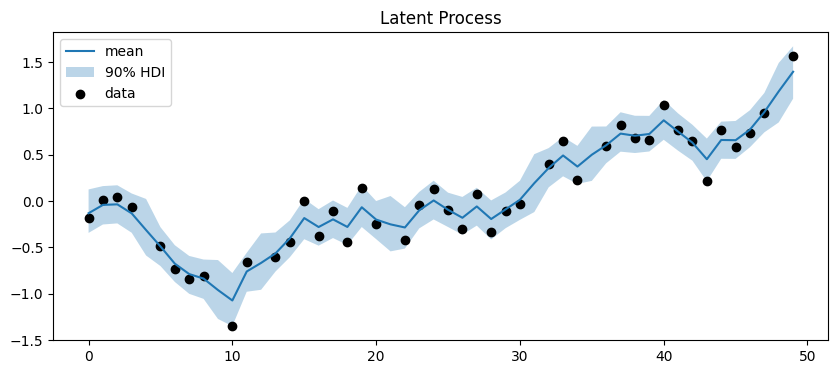

In [17]:
y_post = trace.posterior["y"].mean(dim=("chain", "draw")).values

y_hdi = pm.stats.hdi(trace.posterior["y"], hdi_prob=0.9)
y_hdi_lower = y_hdi["y"].sel(hdi="lower").values
y_hdi_upper = y_hdi["y"].sel(hdi="higher").values

plt.figure(figsize=(10, 4))
plt.plot(y_post, label="mean")
plt.fill_between(np.arange(T), y_hdi_lower, y_hdi_upper, alpha=0.3, label="90% HDI")
plt.scatter(np.where(m == 1), y_obs[m == 1], color="black", label="data")
plt.title("Latent Process")
plt.legend()
plt.show()

## Final Note

For linear-gaussian state-space models, missing observations can often be handled
by analytically conditioning on the observed values (for example, via kalman
filtering).

Here we take a different approach and model the observation process directly.
This makes it possible for missingness itself to inform inference when it depends
on the latent state.